In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.subplot()

In [8]:
import jax.numpy as jnp
import numpy as np 

from sklearn.datasets import fetch_20newsgroups

import matplotlib.pyplot as plt
import seaborn as sns

#from cartm.model import ContextTopicModel
#from cartm.attentive_model import AttentiveTopicModel
from cartm.improved_model import AttentiveTopicModel
from cartm.base_model import BaseContextTopicModel
from cartm.preprocessing import DatasetPreprocessor

In [2]:
from sklearn.datasets import fetch_20newsgroups

This example will guide you through the basic interaction with the model.

## Data preprocessing

First, let's download a sample dataset and preprocess it with `DatasetPreprocessor`.

In [20]:
data = fetch_20newsgroups(data_home='../data/', subset='all').data
print(f'Total number of documents in corpus: {len(data)}')
print(f'Total number of words in corpus: {sum([len(doc.split(" ")) for doc in data])}')

Total number of documents in corpus: 18846
Total number of words in corpus: 5937230


In [21]:
data = data[:400]

In [ ]:
#for line in data:
#    print(line)

In [36]:
with open('./data/test_data.txt') as f:
    data = f.readlines()
print(f'Total number of documents in corpus: {len(data)}')
print(f'Total number of words in corpus: {sum([len(doc.split(" ")) for doc in data])}')

Total number of documents in corpus: 4
Total number of words in corpus: 34


In [22]:
preprocessor = DatasetPreprocessor(stopwords=[], min_word_len=0)
tokenized_data, document_bounds = preprocessor.fit_transform(data)
print(f'Total number of document boundaries in preprocessed corpus: {len(document_bounds)}')
print(f'Total number of tokenized words in preprocessed corpus: {len(tokenized_data)}')

Total number of document boundaries in preprocessed corpus: 401
Total number of tokenized words in preprocessed corpus: 96398


The `DatasetPreprocessor` class handles the filtering and tokenizing of the raw data. Its method `fit_transform` learns the vocabulary of the passed corpus of documents and returns tokenized words from corpus as the first return value, and document bounds as the second return value.

By default, `DatasetPreprocessor` removes stopwords, digits and special characters, therefore the total number of tokenized words is less than the number of words in raw corpus. Document boundaries are at the beginning and ending of the document, therefore the number of boundaries is [number_of_documents] + 1.

The returned values from `fit_transform` have jax.numpy.ndarray type, so you can work with them like a normal arrays.

In [16]:
print(f'Number of unique words in the preprocessed corpus: {jnp.max(tokenized_data)}')

Number of unique words in the preprocessed corpus: 12744


### Accessing vocabulary

You can also access mapping of words to tokens after fitting the preprocessor with data.

In [17]:
vocabulary = preprocessor.vocabulary

for i, (word, token) in enumerate(vocabulary.items()):
    print(f'{word}: {token}')
    if i == 10:
        break

reverse_vocab = {value: key for key, value in vocabulary.items()}
#[reverse_vocab[t] for t in tokenized_data.tolist()]

a: 0
aa: 1
aaa: 2
aaai: 3
aacvkc: 4
aalm: 5
aamir: 6
aanp: 7
aap: 8
aaron: 9
ab: 10


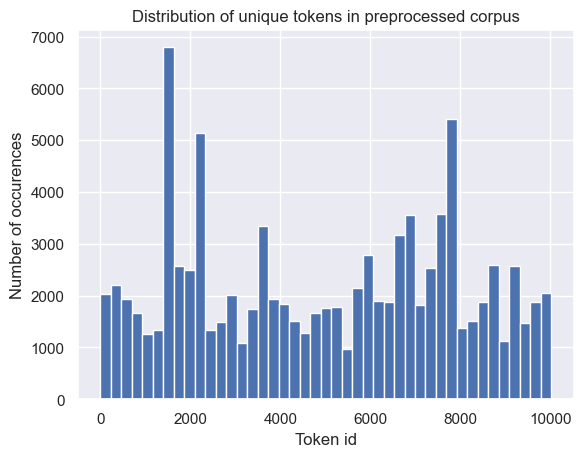

In [7]:
sns.set_theme()

#plt.hist(tokenized_data, bins=100)
plt.hist(tokenized_data, bins='auto')

plt.xlabel('Token id')
plt.ylabel('Number of occurences')
plt.title('Distribution of unique tokens in preprocessed corpus')
#plt.yscale('log')
plt.show()

[('the', np.int64(5577)), ('to', np.int64(2849)), ('a', np.int64(2628)), ('of', np.int64(2611)), ('i', np.int64(2288)), ('and', np.int64(2107)), ('in', np.int64(1852)), ('is', np.int64(1746)), ('that', np.int64(1568)), ('it', np.int64(1313))]
133674


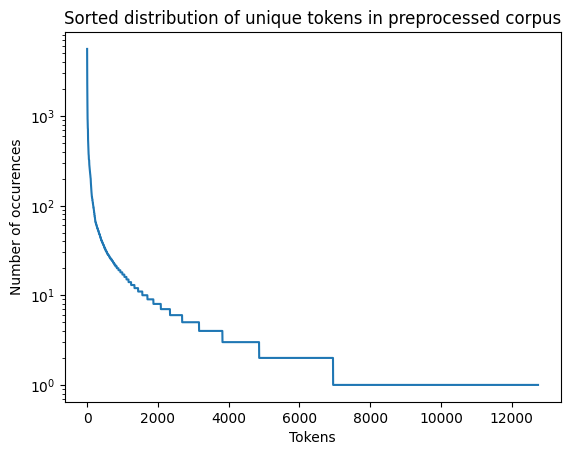

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
data = tokenized_data
tokens, counts = np.unique(tokenized_data, return_counts=True)
sorted_indices = np.argsort(counts)[::-1]
sorted_counts = counts[sorted_indices]
sorted_tokens = tokens[sorted_indices]

print([(reverse_vocab[sorted_tokens[i]], sorted_counts[i]) for i in range(10)])
print(sum(sorted_counts))

plt.plot(sorted_counts)
plt.yscale('log')
plt.xlabel('Tokens')
plt.ylabel('Number of occurences')
plt.title('Sorted distribution of unique tokens in preprocessed corpus')
plt.show()

## Model training

Having the data preprocessed with `DatasetPreprocessor`, we can fit out model pretty straighforwardly.

Please note that calling `fit` method multiple times in one model will discard all results of the previous training.

In [9]:
%load_ext autoreload
%autoreload 2

In [ ]:
topic_model = AttentiveTopicModel(
    vocab_size=len(preprocessor.vocabulary),
    ctx_len=10,
    n_topics=10
)

topic_model.fit(
    data=tokenized_data,
    ctx_bounds=document_bounds,
    verbose=2,
    seed=42,
)

The model training stops because the update diff norm becomes too low. This means that the model has converged. You can modify the convergence threshold and max number of iterations.

You can also modify number of topics and other parameters of the model. Refer to the `fit` funciton docs for more info about model training.

## Analysis

After the model is fitted, you can access its parameters and analyse them.

In [11]:
phi_wt = topic_model.phi  # p(w|t)
n_t = topic_model.n_t  # denormalized distribution of topics
print(f'phi matrix type: {type(phi_wt)}, shape: {phi_wt.shape}')
print(f'n_t array type: {type(n_t)}, shape: {n_t.shape}')

phi matrix type: <class 'jaxlib._jax.ArrayImpl'>, shape: (10022, 10)
n_t array type: <class 'jaxlib._jax.ArrayImpl'>, shape: (10,)


### Plot a histogram of a distribution of topics in corpus:

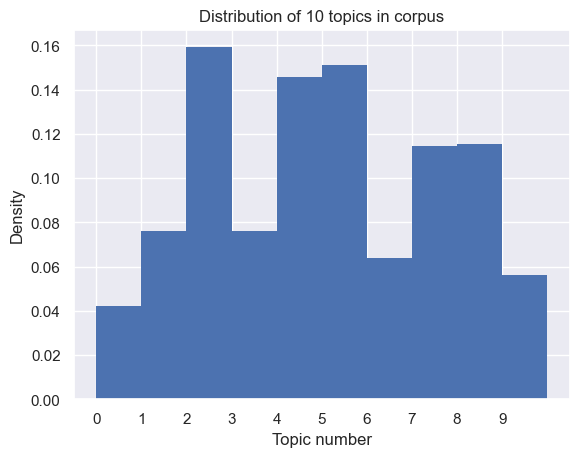

In [12]:
plt.stairs(n_t / n_t.sum(), range(len(n_t) + 1), fill=True)

plt.xticks(range(len(n_t)))
plt.xlabel('Topic number')
plt.ylabel('Density')
plt.title('Distribution of 10 topics in corpus')
plt.show()

### Print top-10 words from each topic:

In [40]:
np.argmax(phi_wt[:, 1])
phi_wt[9257]
#5.4531813e-02
np.max(phi_wt[:, 1])

Array(0.05453181, dtype=float32)

In [13]:
# find top-10 words with the biggest probability p(w|t) for each topic t
topk = jnp.argsort(phi_wt, axis=0, descending=True)[:20, :].T

# create mapping token -> word from existing mapping word -> token (vocabulary)
reverse_vocab = {value: key for key, value in vocabulary.items()}

for topic_idx, t in enumerate(topk):
    print(f'Topic {topic_idx + 1}:', '\t'.join([reverse_vocab[int(idx)] for idx in t]))
    print()

Topic 1: your	in	my	key	from	thank	on	opinion	the	edu	quit	is	for	uiuc	f	defin	and	an	own	are

Topic 2: line	organ	com	univers	of	from	in	comput	uk	distribut	ac	x	articl	world	usa	apr	write	john	sun	research

Topic 3: is	that	it	not	you	are	if	thi	s	they	wa	there	what	but	a	he	about	so	ha	no

Topic 4: edu	subject	re	from	write	articl	in	c	cs	ca	o	e	s	apr	d	david	p	u	b	andrew

Topic 5: the	of	in	a	and	by	law	on	is	one	that	same	christian	an	which	state	thi	part	from	as

Topic 6: i	to	be	have	you	a	can	do	it	would	will	get	that	me	not	but	use	we	think	m

Topic 7: a	as	or	than	and	more	in	new	an	such	is	better	by	from	wa	nasa	space	gov	even	ani

Topic 8: the	and	to	with	s	up	who	for	are	by	their	peopl	were	all	come	hi	in	those	god	off

Topic 9: the	a	for	on	and	at	with	is	use	year	window	of	an	thi	time	my	drive	bit	card	from

Topic 10: t	post	host	nntp	don	edu	from	doesn	write	det	nyr	i	ed	didn	bo	tor	la	uci	mtl	chi



In [14]:
from jax import jit

@jit
def entropy_renyi(matrix, power):
    entropies = jnp.sum(matrix ** power, axis=1)
    #return entropies    
    return entropies / jnp.max(entropies)

In [16]:
entropys = [(s, entropy_renyi(phi_wt, power=s)) for s in np.linspace(1.1, 1.9, num=9)]
print(f"{entropys=}")
cum_entropys = []


entropys=[(np.float64(1.1), Array([0.00108247, 0.0002018 , 0.00012732, ..., 0.0014392 , 0.00046001,
       0.00092506], dtype=float32)), (np.float64(1.2000000000000002), Array([6.4022432e-04, 1.0278490e-04, 6.2186853e-05, ..., 8.7604986e-04,
       2.2978584e-04, 5.4110738e-04], dtype=float32)), (np.float64(1.3), Array([3.77435324e-04, 5.21338552e-05, 3.02484586e-05, ...,
       5.31118654e-04, 1.14409784e-04, 3.15200421e-04], dtype=float32)), (np.float64(1.4), Array([2.2185221e-04, 2.6348920e-05, 1.4660890e-05, ..., 3.2087750e-04,
       5.6812969e-05, 1.8295430e-04], dtype=float32)), (np.float64(1.5), Array([1.30049040e-04, 1.32758641e-05, 7.08393236e-06, ...,
       1.93268264e-04, 2.81499051e-05, 1.05865736e-04], dtype=float32)), (np.float64(1.6), Array([7.6045493e-05, 6.6708353e-06, 3.4135473e-06, ..., 1.1609348e-04,
       1.3922197e-05, 6.1092192e-05], dtype=float32)), (np.float64(1.7), Array([4.4366188e-05, 3.3438173e-06, 1.6409010e-06, ..., 6.9567170e-05,
       6.8748377e-06,

In [17]:
print(f"{phi_wt[0]=}")
print(sum([p_t**1.1 for p_t in phi_wt[0]]))
print(f"{reverse_vocab[0]=}")
print(f"{phi_wt[1]=}")
print(f"{reverse_vocab[1]=}")
print(sum([p_t**1.1 for p_t in phi_wt[1]]))
entropys[0][1][:2]

phi_wt[0]=Array([0.0000000e+00, 7.8249077e-34, 2.9373756e-28, 0.0000000e+00,
       1.0162026e-16, 7.0037436e-06, 1.0121003e-08, 6.2467682e-04,
       2.2546661e-20, 0.0000000e+00], dtype=float32)
0.000300829
reverse_vocab[0]='hook'
phi_wt[1]=Array([0.        , 0.00013655, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ],      dtype=float32)
reverse_vocab[1]='buzz'
5.6083212e-05


Array([0.00108247, 0.0002018 ], dtype=float32)

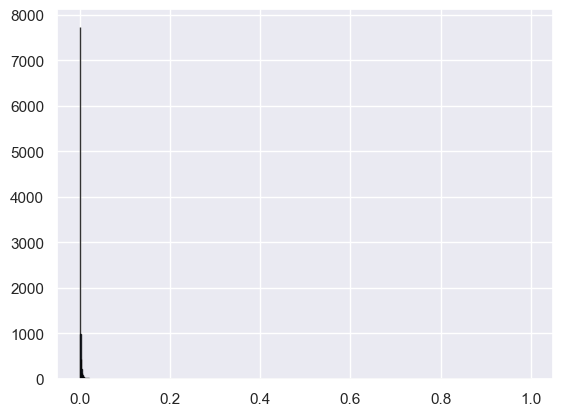

In [18]:
counts, bin_edges, _ = plt.hist(
    entropys[0][1], 
    bins=1000, 
    range=(0, 1),  # фиксированный диапазон
    density=False,
    color='b', 
    edgecolor='black',
    alpha=0.8,
    label='Распределение'
)


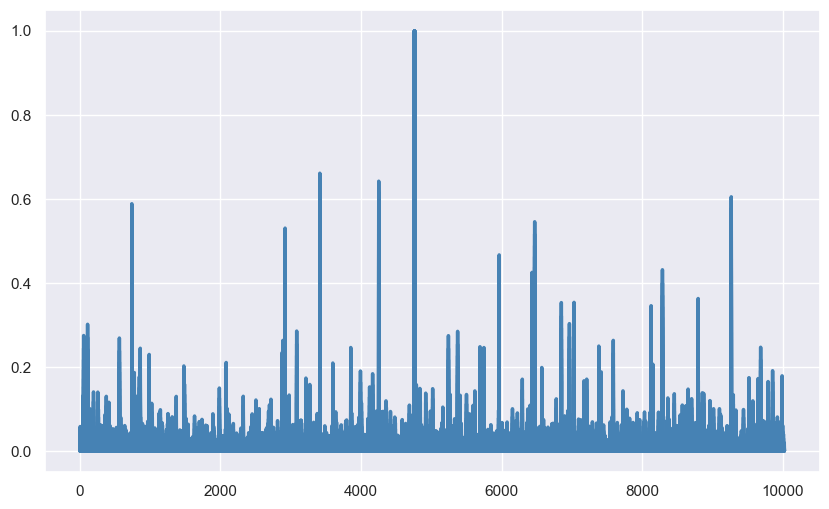

In [57]:

plt.figure(figsize=(10, 6))
for s, entropy in entropys:
    plt.plot(entropy, 
        linestyle='-', linewidth=2.5, markersize=8,
        color='steelblue', markerfacecolor='white', markeredgecolor='steelblue')


In [19]:
def plot_distribution_advanced(data, n_bins=20, figsize=(12, 5), 
                              plot_type='all', bandwidth=None):
    """
    Расширенная визуализация распределения.
    
    Args:
        data: 1D массив чисел в [0, 1]
        n_bins: количество бинов для гистограммы
        figsize: размер фигуры
        plot_type: 'hist' | 'kde' | 'ecdf' | 'all'
        bandwidth: ширина окна для KDE (по умолчанию автоматический выбор)
    
    Returns:
        dict с данными для каждого типа графика
    """
    data = np.asarray(data)
    n = len(data)
    
    results = {}
    
    # === ГИСТОГРАММА ===
    if plot_type in ['hist', 'all']:
        fig, ax = plt.subplots(figsize=figsize)
        counts, bin_edges, _ = ax.hist(
            data, bins=n_bins, range=(0, 1), density=True,
            color='skyblue', edgecolor='black', alpha=0.7, label='Гистограмма'
        )
        ax.set_xlabel('Значение', fontsize=11)
        ax.set_ylabel('Плотность', fontsize=11)
        ax.set_title('Гистограмма распределения', fontsize=13, pad=15)
        ax.grid(True, alpha=0.3, linestyle='--', axis='y')
        ax.set_xlim(0, 1)
        ax.legend()
        plt.tight_layout()
        plt.show()
        
        results['hist'] = {'counts': counts, 'bin_edges': bin_edges}
    
    # === KDE (ядерная оценка плотности) ===
    if plot_type in ['kde', 'all']:
        from scipy.stats import gaussian_kde
        
        # Автоматический bandwidth, если не задан
        if bandwidth is None:
            bandwidth = 1.06 * data.std() * n ** (-1/5)  # правило Сильвермана
        
        # Оценка плотности
        x_eval = np.linspace(0, 1, 200)
        kde = gaussian_kde(data, bw_method=bandwidth / data.std() if data.std() > 0 else 1.0)
        # Обрезаем выбросы KDE за пределами [0, 1]
        density = kde(x_eval)
        density = np.where((x_eval >= 0) & (x_eval <= 1), density, 0)
        
        plt.figure(figsize=figsize)
        plt.plot(x_eval, density, linewidth=2.5, color='darkorange', label='KDE')
        plt.fill_between(x_eval, density, alpha=0.2, color='darkorange')
        plt.xlabel('Значение', fontsize=11)
        plt.ylabel('Плотность', fontsize=11)
        plt.title('Ядерная оценка плотности (KDE)', fontsize=13, pad=15)
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.xlim(0, 1)
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        results['kde'] = {'x': x_eval, 'density': density}
    
    # === ECDF (эмпирическая функция распределения) ===
    if plot_type in ['ecdf', 'all']:
        sorted_data = np.sort(data)
        ecdf = np.arange(1, n + 1) / n
        
        plt.figure(figsize=figsize)
        plt.plot(sorted_data, ecdf, linewidth=2, color='darkgreen', label='ECDF')
        plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Медиана')
        plt.axvline(x=np.median(data), color='red', linestyle=':', alpha=0.5)
        plt.xlabel('Значение', fontsize=11)
        plt.ylabel('Накопленная доля', fontsize=11)
        plt.title('Эмпирическая функция распределения (ECDF)', fontsize=13, pad=15)
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.xlim(0, 1)
        plt.ylim(0, 1.05)
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        results['ecdf'] = {'x': sorted_data, 'ecdf': ecdf}
    
    # Статистика
    #print(f"📊 Статистика данных (n={n})")
    #print(f"   Мин: {data.min():.4f}, Макс: {data.max():.4f}")
    #print(f"   Среднее: {data.mean():.4f}, Медиана: {np.median(data):.4f}")
    #print(f"   Стд. отклонение: {data.std():.4f}")
    #print(f"   Квантили: 25%={np.percentile(data, 25):.4f}, "
    #      f"75%={np.percentile(data, 75):.4f}")
    
    #return results

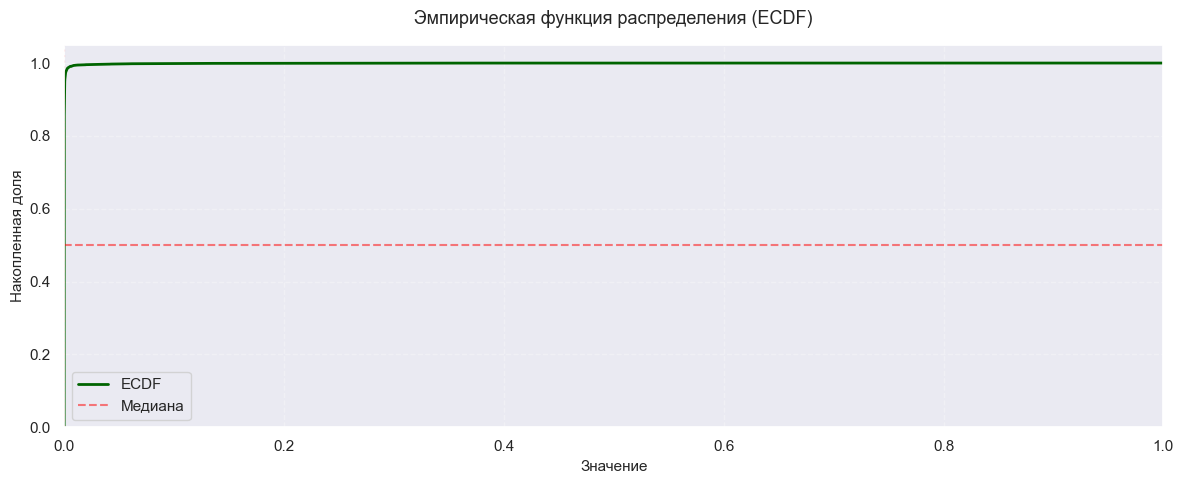

In [27]:
# Разные типы распределений для теста
data_uniform = np.random.uniform(0, 1, 1000)      # равномерное
data_beta = np.random.beta(2, 5, 1000)            # скошено вправо
data_bimodal = np.concatenate([
    np.random.beta(2, 2, 500) * 0.4,              # левый пик
    np.random.beta(2, 2, 500) * 0.4 + 0.6         # правый пик
])

# Построение всех типов графиков
plot_distribution_advanced(entropys[5][1], plot_type='ecdf')

In [21]:
vocabulary['the']

1584

In [29]:
phi_wt[vocabulary['your']]

Array([3.6372498e-02, 1.2770980e-27, 2.9988868e-07, 9.8309083e-33,
       3.9168373e-08, 2.1376538e-03, 1.6427313e-07, 1.8359957e-03,
       1.1290986e-06, 4.8016216e-07], dtype=float32)

In [28]:
phi_wt[:10]

Array([[0.0000000e+00, 7.8249077e-34, 2.9373756e-28, 0.0000000e+00,
        1.0162026e-16, 7.0037436e-06, 1.0121003e-08, 6.2467682e-04,
        2.2546661e-20, 0.0000000e+00],
       [0.0000000e+00, 1.3655346e-04, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 1.8963861e-25, 0.0000000e+00, 0.0000000e+00,
        8.9834626e-05, 0.0000000e+00],
       [1.3086602e-13, 9.2725777e-20, 1.9989069e-05, 0.0000000e+00,
        3.5087103e-03, 7.9472417e-15, 3.8429420e-03, 4.4848896e-03,
        4.3419874e-03, 2.7718291e-29],
       [0.0000000e+00, 1.3655346e-04, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 3.2789574e-27, 0.0000000e+00, 1.3626086e-04,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.00